In [2]:
# Baixa o dataset do Kaggle
!kaggle datasets download -d mlg-ulb/creditcardfraud

# Descompacta o arquivo
!unzip creditcardfraud.zip

print("Dados baixados!")

Dataset URL: https://www.kaggle.com/datasets/mlg-ulb/creditcardfraud
License(s): DbCL-1.0
100% 66.0M/66.0M [00:03<00:00, 20.4MB/s]

Archive:  creditcardfraud.zip
  inflating: creditcard.csv          
Dados baixados!


In [3]:
# Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve
from xgboost import XGBClassifier
import shap
import warnings
warnings.filterwarnings('ignore')

print("Libs carregadas!")

Libs carregadas!


In [4]:

# Carrega o dataset
df = pd.read_csv('creditcard.csv')

# Primeiras informações básicas
print("Shape do dataset:", df.shape)
print("\nPrimeiras linhas:")
df.head()

Shape do dataset: (284807, 31)

Primeiras linhas:


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [5]:
# Quantas fraudes existem no dataset?
print("Distribuição da variável alvo (Class):")
print(df['Class'].value_counts())

print("\nEm percentual:")
print(df['Class'].value_counts(normalize=True) * 100)

Distribuição da variável alvo (Class):
Class
0    284315
1       492
Name: count, dtype: int64

Em percentual:
Class
0    99.827251
1     0.172749
Name: proportion, dtype: float64


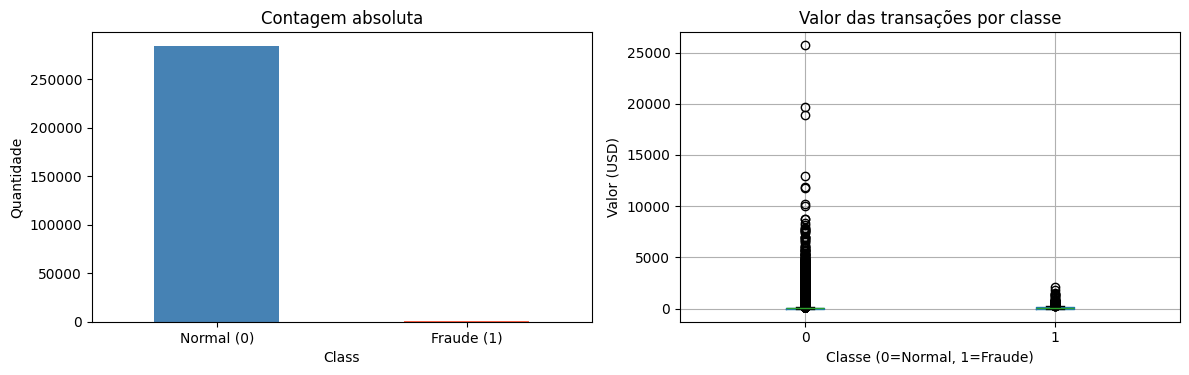

In [6]:


# Gráfico de distribuição das classes
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Contagem absoluta
df['Class'].value_counts().plot(kind='bar', ax=axes[0], color=['steelblue', 'tomato'])
axes[0].set_title('Contagem absoluta')
axes[0].set_xticklabels(['Normal (0)', 'Fraude (1)'], rotation=0)
axes[0].set_ylabel('Quantidade')

# Valor das transações: normal vs fraude
df.boxplot(column='Amount', by='Class', ax=axes[1])
axes[1].set_title('Valor das transações por classe')
axes[1].set_xlabel('Classe (0=Normal, 1=Fraude)')
axes[1].set_ylabel('Valor (USD)')

plt.suptitle('')
plt.tight_layout()
plt.show()

In [7]:
# Comparando valores médios
print("Valor médio das transações:")
print(df.groupby('Class')['Amount'].describe())

Valor médio das transações:
          count        mean         std  min   25%    50%     75%       max
Class                                                                      
0      284315.0   88.291022  250.105092  0.0  5.65  22.00   77.05  25691.16
1         492.0  122.211321  256.683288  0.0  1.00   9.25  105.89   2125.87


In [8]:
# A coluna Time não agrega muito para o modelo, vamos remover
# Amount precisa ser normalizado pois está em escala diferente das features V1-V28

scaler = StandardScaler()

df['Amount_scaled'] = scaler.fit_transform(df[['Amount']])
df = df.drop(columns=['Time', 'Amount'])

# Separando features (X) e target (y)
X = df.drop(columns=['Class'])
y = df['Class']

print("Shape de X:", X.shape)
print("Shape de y:", y.shape)

Shape de X: (284807, 29)
Shape de y: (284807,)


In [9]:
# Dividindo em treino e teste
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,       # 20% para teste, 80% para treino
    random_state=42,     # garante que o resultado seja reproduzível
    stratify=y           # mantém a proporção de fraudes nos dois conjuntos
)

print("Tamanho do treino:", X_train.shape)
print("Tamanho do teste:", X_test.shape)
print("\nFraudes no treino:", y_train.sum())
print("Fraudes no teste:", y_test.sum())

Tamanho do treino: (227845, 29)
Tamanho do teste: (56962, 29)

Fraudes no treino: 394
Fraudes no teste: 98


In [10]:
# Treinando o XGBoost
modelo = XGBClassifier(
    scale_pos_weight=len(y_train[y_train==0]) / len(y_train[y_train==1]),  # lida com o desbalanceamento
    random_state=42,
    eval_metric='aucpr'
)

modelo.fit(X_train, y_train)

print("Modelo treinado!")

Modelo treinado!


In [11]:
# Fazendo previsões
y_pred = modelo.predict(X_test)

# Relatório completo
print("Relatório de Classificação:")
print(classification_report(y_test, y_pred, target_names=['Normal', 'Fraude']))


Relatório de Classificação:
              precision    recall  f1-score   support

      Normal       1.00      1.00      1.00     56864
      Fraude       0.88      0.85      0.86        98

    accuracy                           1.00     56962
   macro avg       0.94      0.92      0.93     56962
weighted avg       1.00      1.00      1.00     56962



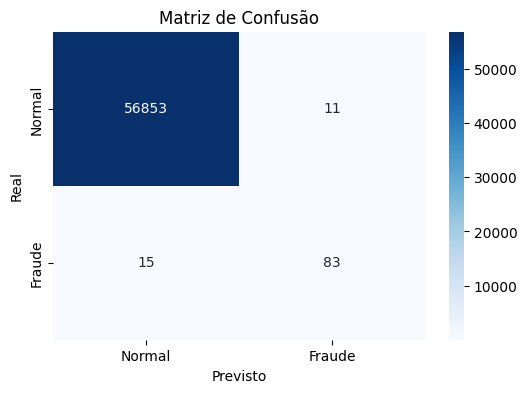

In [12]:
# Matriz de confusão
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Normal', 'Fraude'],
            yticklabels=['Normal', 'Fraude'])
plt.title('Matriz de Confusão')
plt.ylabel('Real')
plt.xlabel('Previsto')
plt.show()

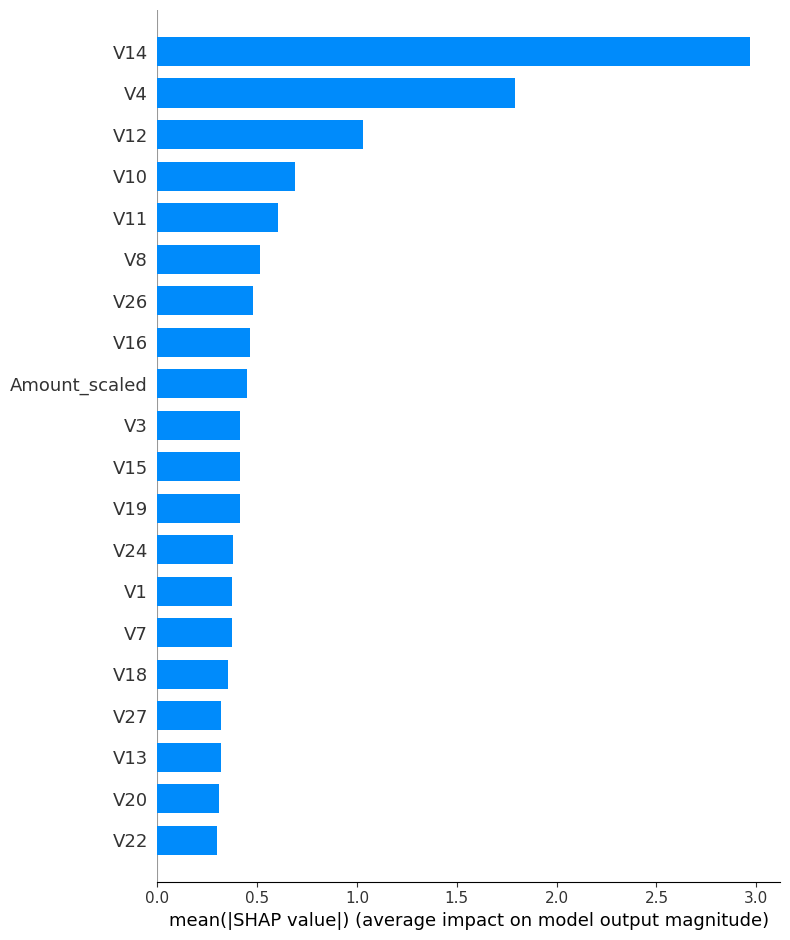

In [13]:
# Explicabilidade com SHAP
explainer = shap.TreeExplainer(modelo)
shap_values = explainer.shap_values(X_test)

# Gráfico de importância global das features
shap.summary_plot(shap_values, X_test, plot_type="bar")

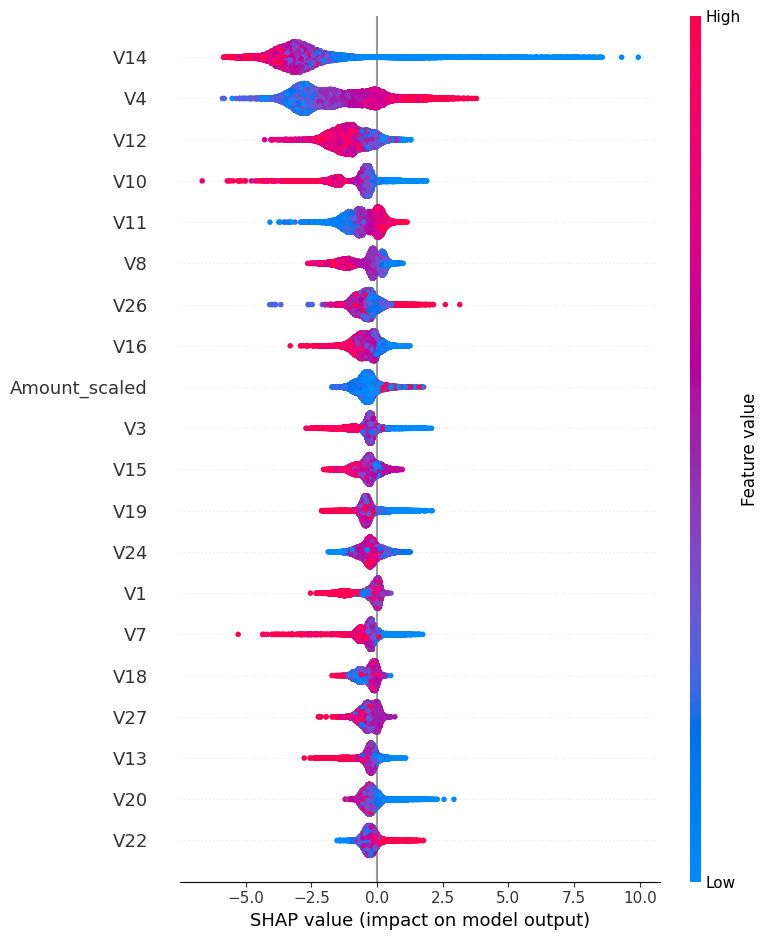

In [14]:
# Summary plot com impacto dos valores
shap.summary_plot(shap_values, X_test)

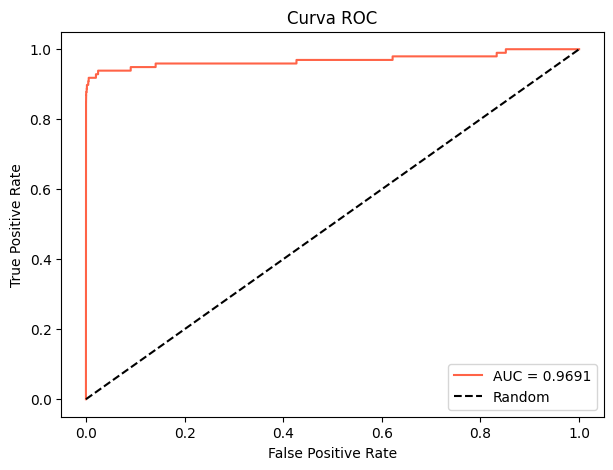

In [15]:
# Curva ROC
y_prob = modelo.predict_proba(X_test)[:, 1]
fpr, tpr, _ = roc_curve(y_test, y_prob)
auc = roc_auc_score(y_test, y_prob)

plt.figure(figsize=(7, 5))
plt.plot(fpr, tpr, color='tomato', label=f'AUC = {auc:.4f}')
plt.plot([0, 1], [0, 1], 'k--', label='Random')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Curva ROC')
plt.legend()
plt.show()